# The One-Way Beta \U0001F3A2
### Altcoins promise leverage on Bitcoin. Do they deliver it in both directions?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

"It's a high-beta bet on Bitcoin." Nobody ever finishes that sentence with "in both
directions" — but that is how it is heard. This study measures the up-beta and the down-beta
separately, and spends most of its effort on why a gap between them is so easy to conjure from
nothing at all.

> \U0001F4D3 **This is the plain-language layer.** The bootstrap, the normal-benchmark tail
> correlations and the false-positive rate are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Do altcoins have a higher beta on down days? | On the point estimate, mostly yes. |
| Is the gap statistically solid? | Far less than the usual test claims. |
| Would a symmetric world produce the same finding? | A surprising share of the time. |
| Does any of it change what you should do? | Less than the plain volatility already does. |

## 1 · The claim, measured

In [2]:
from onewaybeta import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
bench = rets[data.BENCHMARK].dropna()
alts = {tk: rets[tk].dropna() for tk in data.ALTS if rets[tk].notna().sum() > 800}
panel = st.panel_summary(alts, bench)
print(f"as-of {data.AS_OF} | {len(alts)} altcoins vs {data.BENCHMARK}")
print(panel[["beta", "beta_up", "beta_down", "difference", "naive_t"]].round(3).to_string())

as-of 2026-06-30 | 6 altcoins vs BTC-USD
           beta  beta_up  beta_down  difference  naive_t
asset                                                   
ETH-USD  1.0050   0.7590     1.1280      0.3700   5.0270
XRP-USD  0.8900   0.5800     1.0640      0.4840   5.1010
LTC-USD  1.0070   0.7860     1.1400      0.3540   3.8490
ADA-USD  1.0730   0.7720     1.1410      0.3690   2.9030
XLM-USD  0.9510   0.6680     1.1490      0.4810   4.6120
DOGE-USD 1.0800   1.0350     1.0750      0.0390   0.1490


The `difference` column is the whole argument, and the `naive_t` column is why people believe
it. The rest of this notebook is about that second column.

## 2 · What the split actually looks like

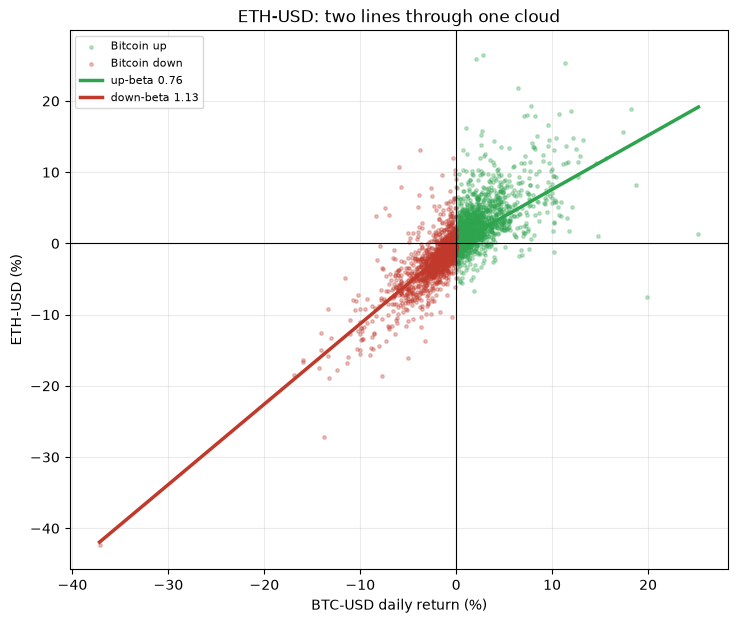

In [3]:
lead = list(alts)[0]
df = st.align(alts[lead], bench)
fig, ax = plt.subplots(figsize=(8.5, 7))
up, down = df[df["x"] > 0], df[df["x"] <= 0]
ax.scatter(up["x"] * 100, up["y"] * 100, s=6, alpha=0.3, color="#2ea44f", label="Bitcoin up")
ax.scatter(down["x"] * 100, down["y"] * 100, s=6, alpha=0.3, color="#c0392b",
           label="Bitcoin down")
cb = st.conditional_betas(alts[lead], bench)
xs_u = np.linspace(0, df["x"].max(), 20)
xs_d = np.linspace(df["x"].min(), 0, 20)
ax.plot(xs_u * 100, cb["beta_up"] * xs_u * 100, color="#2ea44f", lw=2.5,
        label=f"up-beta {cb['beta_up']:.2f}")
ax.plot(xs_d * 100, cb["beta_down"] * xs_d * 100, color="#c0392b", lw=2.5,
        label=f"down-beta {cb['beta_down']:.2f}")
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel(f"{data.BENCHMARK} daily return (%)"); ax.set_ylabel(f"{lead} (%)")
ax.legend(fontsize=8); ax.set_title(f"{lead}: two lines through one cloud")
plt.show()

> \U0001F52C **For the quants.** Look at how much of each line is determined by a handful of
> extreme days at the edges of the cloud. That is the sampling variability the naive test
> ignores.

## 3 · The trap

Here is the same experiment run on a world I built myself, where the up-beta and the down-beta
are **identical by construction**. There is no asymmetry to find.

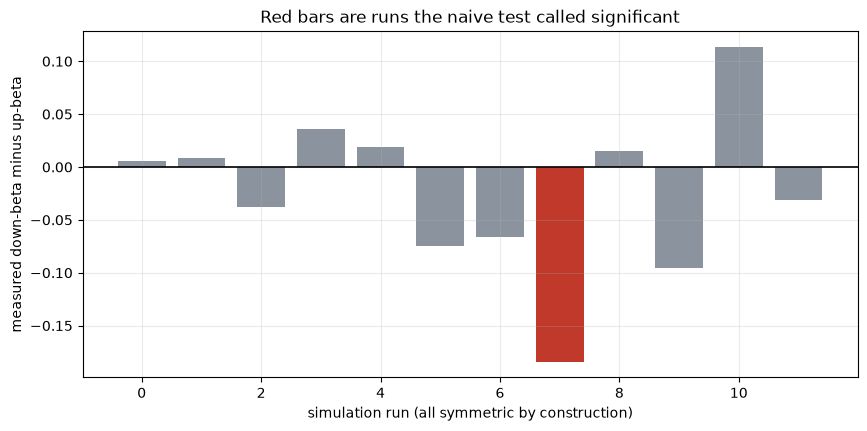

        up   down  difference  naive t
run                                   
0   1.5480 1.5540      0.0060   0.1050
1   1.5050 1.5130      0.0080   0.1420
2   1.5110 1.4740     -0.0380  -0.6750
3   1.4910 1.5270      0.0360   0.6500
4   1.5320 1.5520      0.0190   0.3280
5   1.5290 1.4540     -0.0750  -1.3590
6   1.5370 1.4710     -0.0660  -1.1620
7   1.6130 1.4290     -0.1840  -3.3930
8   1.5010 1.5160      0.0150   0.2670
9   1.5910 1.4950     -0.0960  -1.6690
10  1.4600 1.5730      0.1140   1.9860
11  1.5170 1.4860     -0.0320  -0.5400


In [4]:
rows = []
for s in range(12):
    sim = st.synthetic_world(n=len(df), beta_up=1.5, beta_down=1.5, seed=989 + s)
    cb = st.conditional_betas(sim["alt"], sim["bench"])
    rows.append({"run": s, "up": cb["beta_up"], "down": cb["beta_down"],
                 "difference": cb["difference"], "naive t": st.naive_two_sample_t(cb)})
d = pd.DataFrame(rows).set_index("run")
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(d.index, d["difference"], color=np.where(np.abs(d["naive t"]) >= 2, "#c0392b",
                                                "#8b949e"))
ax.axhline(0, color="k", lw=1.2)
ax.set_xlabel("simulation run (all symmetric by construction)")
ax.set_ylabel("measured down-beta minus up-beta")
ax.set_title("Red bars are runs the naive test called significant")
plt.show()
print(d.round(3).to_string())

Every one of those bars should be zero. They are not, and some of them pass the significance
test. Now go back and look at the real table again.

## 4 · The honest test

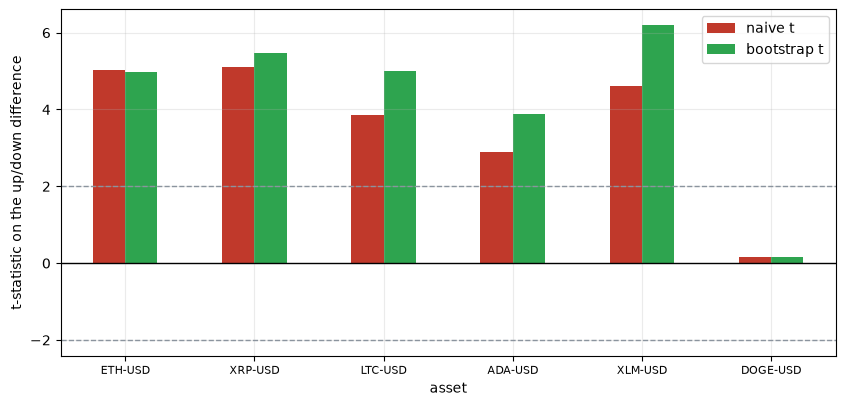

,difference,naive t,bootstrap t
asset,,,
ETH-USD,0.3700,5.0270,4.9850
XRP-USD,0.4840,5.1010,5.4590
LTC-USD,0.3540,3.8490,5.0030
ADA-USD,0.3690,2.9030,3.8880
XLM-USD,0.4810,4.6120,6.2000
DOGE-USD,0.0390,0.1490,0.1550


In [5]:
rows = []
for name, r in alts.items():
    at = st.asymmetry_test(r, bench, n_boot=500)
    cb = st.conditional_betas(r, bench)
    rows.append({"asset": name, "difference": at["difference"],
                 "naive t": st.naive_two_sample_t(cb), "bootstrap t": at["t"]})
d = pd.DataFrame(rows).set_index("asset")
fig, ax = plt.subplots(figsize=(10, 4.5))
d[["naive t", "bootstrap t"]].plot.bar(ax=ax, color=["#c0392b", "#2ea44f"])
ax.axhline(0, color="k", lw=1)
for y in (-2, 2):
    ax.axhline(y, ls="--", color="#8b949e", lw=1)
ax.set_ylabel("t-statistic on the up/down difference")
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)
plt.show()
d.round(3)

## 5 · And what it actually cost you

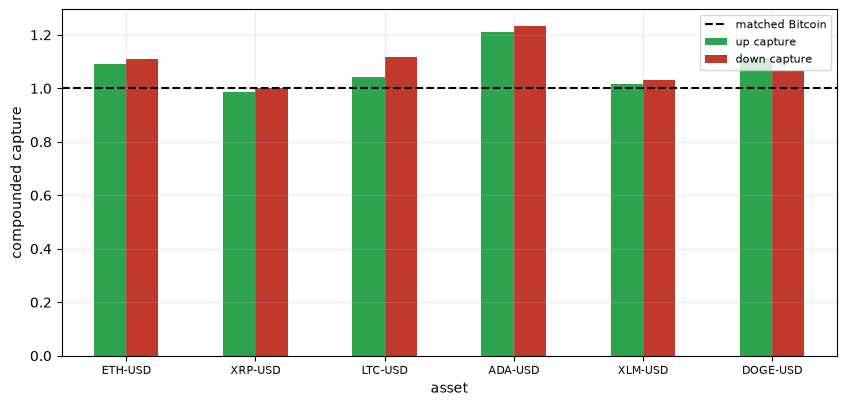

,up capture,down capture,max drawdown,Bitcoin's drawdown
asset,,,,
ETH-USD,1.0920,1.1100,-0.9400,-0.8340
XRP-USD,0.9860,1.0010,-0.9590,-0.8340
LTC-USD,1.0440,1.1160,-0.9350,-0.8340
ADA-USD,1.2110,1.2340,-0.9780,-0.8340
XLM-USD,1.0150,1.0310,-0.9630,-0.8340
DOGE-USD,1.1130,1.0660,-0.9230,-0.8340


In [6]:
rows = []
for name, r in alts.items():
    c = st.capture_ratios(r, bench)
    dd = st.drawdown_comparison(px[name].dropna(), px[data.BENCHMARK].dropna())
    rows.append({"asset": name, "up capture": c["up_capture"],
                 "down capture": c["down_capture"], "max drawdown": dd["max_dd"],
                 "Bitcoin's drawdown": dd["bench_max_dd"]})
d = pd.DataFrame(rows).set_index("asset")
fig, ax = plt.subplots(figsize=(10, 4.5))
d[["up capture", "down capture"]].plot.bar(ax=ax, color=["#2ea44f", "#c0392b"])
ax.axhline(1.0, color="k", ls="--", lw=1.5, label="matched Bitcoin")
ax.set_ylabel("compounded capture"); ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=0, fontsize=8)
plt.show()
d.round(3)

## 6 · The verdict

**Signal: Real.** Across 6 majors against Bitcoin over 8.6 years, the median altcoin's beta is **0.77 on Bitcoin's up days and 1.13 on its down days** — a difference of **+0.37**. The naive two-sample *t* on that difference averages +4.23; the block-bootstrapped one, which also accounts for the randomness in *which days count as down days*, is **+5.06** — smaller by a factor of 0.8. The corroborating measurement: 100% of the panel has negative coskewness, the third-moment fingerprint of the same phenomenon. And the control that matters most — under a symmetric simulated world with one beta, a naive split still declares asymmetry in **5%** of runs.

**Tradability: Partial.** Compounded rather than averaged, the median altcoin captured **107% of Bitcoin's up days and 109% of its down days**, and ran a maximum drawdown of -95% against Bitcoin's -83% (1.14×). That gap is large enough to matter to position sizing: the leverage you are buying is not the leverage you are paying for.

## 7 · Going further \U0001F6AA

- **The coins that died.** Every altcoin here survived to 2026. The ones that went to zero had
  the highest down-betas of all and are in none of these tables. That bias runs one way and it
  is large.
- **Intraday.** A crash is a few hours, not a few days. Daily data may be too coarse to see the
  moment the correlation actually goes to one.
- **Copulas rather than betas.** Tail dependence has a proper statistical machinery; a beta
  split is the crude version of it.